<a href="https://colab.research.google.com/github/Moali1749/-sma-backtester/blob/main/Backtester_1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance --upgrade


In [ ]:
import yfinance as yf
import pandas as pd


In [ ]:
data = yf.download("AAPL", start="2015-01-01", end="2025-01-01", auto_adjust=True)


[*********************100%***********************]  1 of 1 completed


In [ ]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192598,24.659500,23.754462,24.648436,212818400
2015-01-05,23.511063,24.042136,23.325188,23.962475,257142000
2015-01-06,23.513275,23.772173,23.152587,23.575233,263188400
2015-01-07,23.842981,23.942557,23.610636,23.721276,160423600
2015-01-08,24.759075,24.816609,24.053190,24.170470,237458000


In [ ]:
data.shape

(2516, 5)

In [ ]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-12-24,256.560822,256.570737,253.669277,253.868019,23234700
2024-12-26,257.375549,258.448710,255.994390,256.550832,27237100
2024-12-27,253.967392,257.057664,251.453455,256.193162,42355300
2024-12-30,250.598923,251.890673,249.158131,250.628731,35557500
2024-12-31,248.830215,251.672059,247.846495,250.837396,39480700


In [ ]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [ ]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


In [ ]:
data.columns


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [ ]:
close = data["Close"]


In [ ]:
close.head()


,Close
Date,
2015-01-02,24.192598
2015-01-05,23.511063
2015-01-06,23.513275
2015-01-07,23.842981
2015-01-08,24.759075


In [ ]:
returns = close.pct_change()


In [ ]:
returns.head()


,Close
Date,
2015-01-02,NaN
2015-01-05,-0.028171
2015-01-06,0.000094
2015-01-07,0.014022
2015-01-08,0.038422


In [ ]:
sma20 = close.rolling(window=20).mean()


In [ ]:
sma20.tail()

Ticker,AAPL
Date,
2024-12-24,244.729903
2024-12-26,245.920295
2024-12-27,246.946738
2024-12-30,247.685518
2024-12-31,248.223581


In [ ]:
df = pd.DataFrame({
    "close": close,
    "returns": returns,
    "sma20": sma20
})


In [ ]:
print(type(close))
print(type(returns))
print(type(sma20))


<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [ ]:
signal_raw = df["close"] > df["sma20"]


In [ ]:
signal_raw.tail(25)

,0
Date,
2024-11-25,True
2024-11-26,True
2024-11-27,True
2024-11-29,True
2024-12-02,True
2024-12-03,True
2024-12-04,True
2024-12-05,True
2024-12-06,True


In [ ]:
signal_raw.value_counts()


,count
True,1557
False,959


In [ ]:
df["signal_raw"] = signal_raw
df[df["signal_raw"] != df["signal_raw"].shift(1)].head(20)


,close,returns,sma20,signal_raw
Date,,,,
2015-01-02,24.192598,NaN,NaN,False
2015-01-30,25.925234,-0.014634,24.482812,True
2015-03-05,28.082472,-0.016570,28.210987,False
2015-03-18,28.540104,0.011256,28.359940,True
2015-03-19,28.324619,-0.007550,28.349388,False
2015-03-23,28.260195,0.010405,28.245087,True
2015-03-24,28.144680,-0.004088,28.184217,False
2015-03-30,28.073586,0.025315,27.967394,True
2015-03-31,27.642607,-0.015352,27.912634,False


In [ ]:
df["signal"] = signal_raw.astype(int)


In [ ]:
df["position"] = df["signal"].shift(1)


In [ ]:
df[["close", "sma20", "signal", "position"]].head(25)


,close,sma20,signal,position
Date,,,,
2015-01-02,24.192598,NaN,0,NaN
2015-01-05,23.511063,NaN,0,0.0
2015-01-06,23.513275,NaN,0,0.0
2015-01-07,23.842981,NaN,0,0.0
2015-01-08,24.759075,NaN,0,0.0
2015-01-09,24.785637,NaN,0,0.0
2015-01-12,24.174894,NaN,0,0.0
2015-01-13,24.389544,NaN,0,0.0
2015-01-14,24.296600,NaN,0,0.0


In [ ]:
df["strategy"] = df["position"] * df["returns"]


In [ ]:
df[["returns", "position", "strategy"]].head(40)


,returns,position,strategy
Date,,,
2015-01-02,NaN,NaN,NaN
2015-01-05,-0.028171,0.0,-0.000000
2015-01-06,0.000094,0.0,0.000000
2015-01-07,0.014022,0.0,0.000000
2015-01-08,0.038422,0.0,0.000000
2015-01-09,0.001073,0.0,0.000000
2015-01-12,-0.024641,0.0,-0.000000
2015-01-13,0.008879,0.0,0.000000
2015-01-14,-0.003811,0.0,-0.000000


In [ ]:
print("Акция (buy & hold):", df["returns"].mean())
print("Стратегия:         ", df["strategy"].mean())


Акция (buy & hold): 0.0010878564546967378
Стратегия:          0.0010621051788957461


In [ ]:
df = df.dropna()


In [ ]:
df.shape

(2497, 7)

In [ ]:
df["equity_holding"] = (1 + df["returns"]).cumprod()


In [ ]:
df["equity_strategy"] = (1 + df["strategy"]).cumprod()


In [ ]:
df[["equity_holding", "equity_strategy"]].tail()


,equity_holding,equity_strategy
Date,,
2024-12-24,9.751361,12.552602
2024-12-26,9.782327,12.592464
2024-12-27,9.652790,12.425715
2024-12-30,9.524762,12.260908
2024-12-31,9.457536,12.174371


In [ ]:
import matplotlib.pyplot as plt


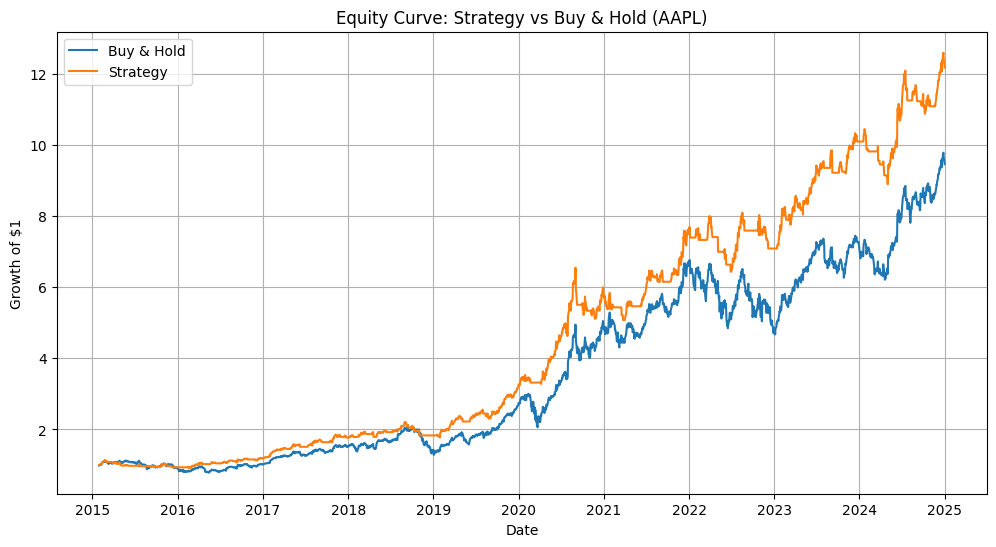

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["equity_holding"], label="Buy & Hold")
plt.plot(df.index, df["equity_strategy"], label="Strategy")
plt.legend()
plt.title("Equity Curve: Strategy vs Buy & Hold (AAPL)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()
